In [1]:
import numpy as np
import pandas as pd
import scanpy as sc 

adata = sc.read_h5ad("dataset_co_mo.h5ad")

In [2]:
# Extract source and receiver genes efficiently
gl_source = ['TGFBR2', 'SMAD3', 'HIF1A', 'PDGFB'] # All values from the first column
gl_recv =['TGFB1', 'FN1', 'PDGFRB']  # All values from the second column

ict1 = adata.obs["BatchID"] == "Cancer Cells (Co)"
ict2 = adata.obs["BatchID"] == "Fibroblasts (Co)" 
adata_ct1_co = adata[ict1, gl_source]
adata_ct2_co = adata[ict2, gl_recv]
print(adata_ct1_co)
print(adata_ct2_co)

Xct1_co = adata_ct1_co.X.copy()
Xct2_co = adata_ct2_co.X.copy()
Xct1_co = np.log1p(Xct1_co)
Xct2_co = np.log1p(Xct2_co)
Xct1_co = Xct1_co.toarray()
Xct2_co = Xct2_co.toarray()
# Assuming Xct1_co and Xct2 are your log-transformed expression matrices
Xct1means = np.mean(Xct1_co, axis=0)
Xct2means = np.mean(Xct2_co, axis=0)

print("CT1 (Co) mean expression:", Xct1means)
print("CT2 (Co) mean expression:", Xct2means)

# Binarize Xct1
Xct1_binary_co = (Xct1_co > Xct1means).astype(int)
# Binarize Xct2
Xct2_binary_co = (Xct2_co > Xct2means).astype(int)

# Calculate the proportion of cells with expression above mean for each gene in ct1
Xct1p_co = np.sum(Xct1_binary_co, axis=0) / len(Xct1_binary_co[:, 0])
# Calculate the proportion of cells with expression above mean for each gene in ct2
Xct2p_co = np.sum(Xct2_binary_co, axis=0) / len(Xct2_binary_co[:, 0])

print("CT1 (Co) Percentages:", Xct1p_co)
print("CT2 (Co) Percentages:", Xct2p_co)

# Scale the data from 0 to 1 to -pi/2 to pi/2 | 2*pi or pi?
ct1_percentages_co = Xct1p_co * np.pi*2
ct2_percentages_co = Xct2p_co * np.pi*2
# Display the resulting scaled data
print("Scaled (Co) (Cct1_data:\n", ct1_percentages_co)
print("Scaled (Co) ct2_data:\n", ct2_percentages_co)

View of AnnData object with n_obs × n_vars = 1414 × 4
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
View of AnnData object with n_obs × n_vars = 1324 × 3
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
CT1 (Co) mean expression: [0.3152271  1.1051539  1.422991   0.29992977]
CT2 (Co) mean expression: [0.488964   2.6829033  0.36402878]
CT1 (Co) Percentages: [0.3748232  0.4427157  0.48868458 0.29915134]
CT2 (Co) Percentages: [0.51812689 0.52114804 0.41993958]
Scaled (Co) (Cct1_data:
 [2.3550836  2.78166478 3.07049579 1.87962333]
Scaled (Co) ct2_data:
 [3.25548725 3.27446968 2.63855818]


In [3]:
ict1 = adata.obs["BatchID"] == "Cancer Cells (Mo)"
ict2 = adata.obs["BatchID"] == "Fibroblasts (Mo)" 
adata_ct1_mo = adata[ict1, gl_source]
adata_ct2_mo = adata[ict2, gl_recv]
print(adata_ct1_mo)
print(adata_ct2_mo)

Xct1_mo = adata_ct1_mo.X.copy()
Xct2_mo = adata_ct2_mo.X.copy()
Xct1_mo = np.log1p(Xct1_mo)
Xct2_mo = np.log1p(Xct2_mo)
Xct1_mo = Xct1_mo.toarray()
Xct2_mo = Xct2_mo.toarray()

# Utilize the mono cultured means here
# Binarize Xct1
Xct1_binary_mo = (Xct1_mo > Xct1means).astype(int)
# Binarize Xct2
Xct2_binary_mo = (Xct2_mo > Xct2means).astype(int)

# Calculate the proportion of cells with expression above mean for each gene in ct1
Xct1p_mo = np.sum(Xct1_binary_mo, axis=0) / len(Xct1_binary_mo[:, 0])

# Calculate the proportion of cells with expression above mean for each gene in ct2
Xct2p_mo = np.sum(Xct2_binary_mo, axis=0) / len(Xct2_binary_mo[:, 0])

print("CT1 (Mo) Percentages:", Xct1p_mo)
print("CT2 (Mo) Percentages:", Xct2p_mo)

# Scale the data from 0 to 1 to -pi/2 to pi/2 | 2*pi or pi?
ct1_percentages_mo = Xct1p_mo * np.pi*2
ct2_percentages_mo = Xct2p_mo * np.pi*2
# Display the resulting scaled data
print("Scaled (Mo) ct1_data:\n", ct1_percentages_mo)
print("Scaled (Mo) ct2_data:\n", ct2_percentages_mo)

View of AnnData object with n_obs × n_vars = 2364 × 4
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
View of AnnData object with n_obs × n_vars = 2788 × 3
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
CT1 (Mo) Percentages: [0.36759729 0.44754653 0.51818951 0.09898477]
CT2 (Mo) Percentages: [0.42969871 0.38020086 0.29196557]
Scaled (Mo) ct1_data:
 [2.30968191 2.81201779 3.25588071 0.62193966]
Scaled (Mo) ct2_data:
 [2.69987661 2.38887246 1.83447376]


In [4]:
import sys
import os

# Replace with your actual path
cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
sys.path.append(cc_grn_functions_path)

from histogram_functions import create_joint_histogram, plot_joint_histogram

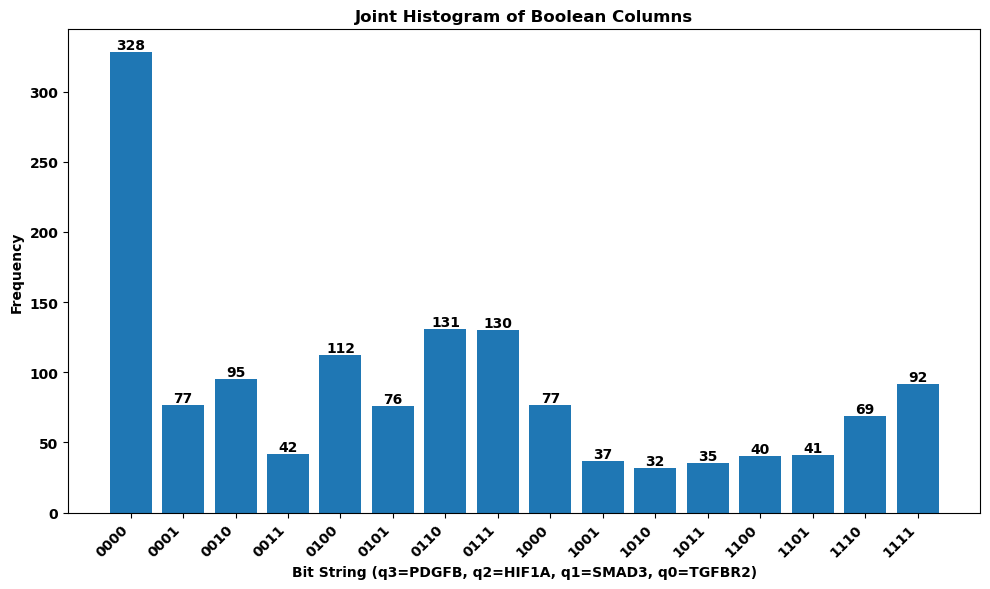

Joint Counts: Counter({'0000': 328, '0110': 131, '1110': 130, '0010': 112, '0100': 95, '1111': 92, '0001': 77, '1000': 77, '1010': 76, '0111': 69, '1100': 42, '1011': 41, '0011': 40, '1001': 37, '1101': 35, '0101': 32})
Bit Strings: ['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111', '1000', '1001', '1010', '1011', '1100', '1101', '1110', '1111']


In [5]:
joint_counts_ct1_co, bit_strings_ct1_co = create_joint_histogram(Xct1_binary_co)

num_qubits = Xct1_binary_co.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct1_co, num_qubits, reverse_bits=True, features=gl_source)  # Pass num_qubits

print("Joint Counts:", joint_counts_ct1_co)
print("Bit Strings:", bit_strings_ct1_co)

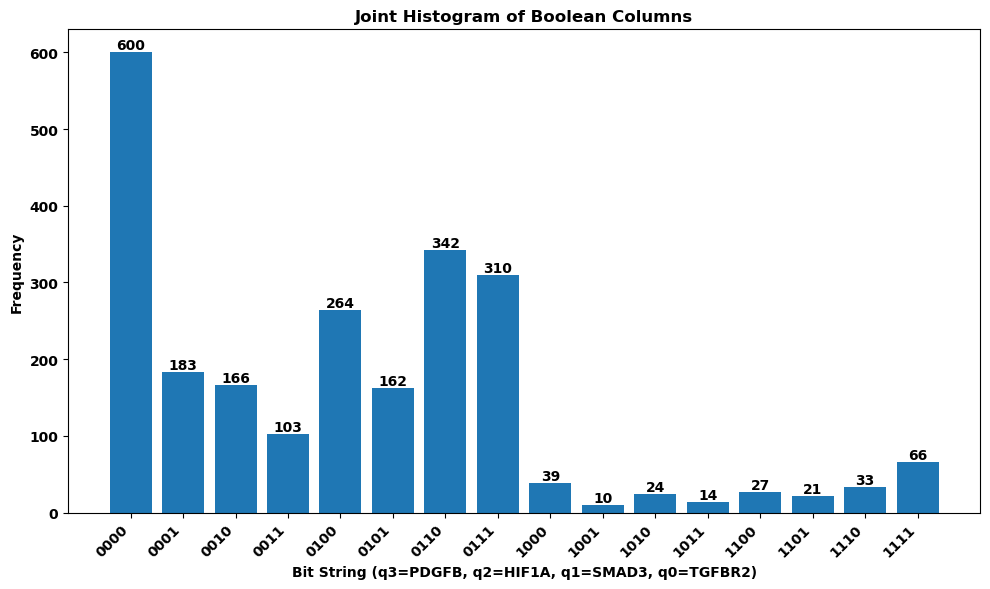

Joint Counts: Counter({'0000': 600, '0110': 342, '1110': 310, '0010': 264, '1000': 183, '0100': 166, '1010': 162, '1100': 103, '1111': 66, '0001': 39, '0111': 33, '0011': 27, '0101': 24, '1011': 21, '1101': 14, '1001': 10})
Bit Strings: ['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111', '1000', '1001', '1010', '1011', '1100', '1101', '1110', '1111']


In [6]:
joint_counts_ct1_mo, bit_strings_ct1_mo = create_joint_histogram(Xct1_binary_mo)

num_qubits = Xct1_binary_mo.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct1_mo, num_qubits, reverse_bits=True, features=gl_source )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct1_mo)
print("Bit Strings:", bit_strings_ct1_mo)

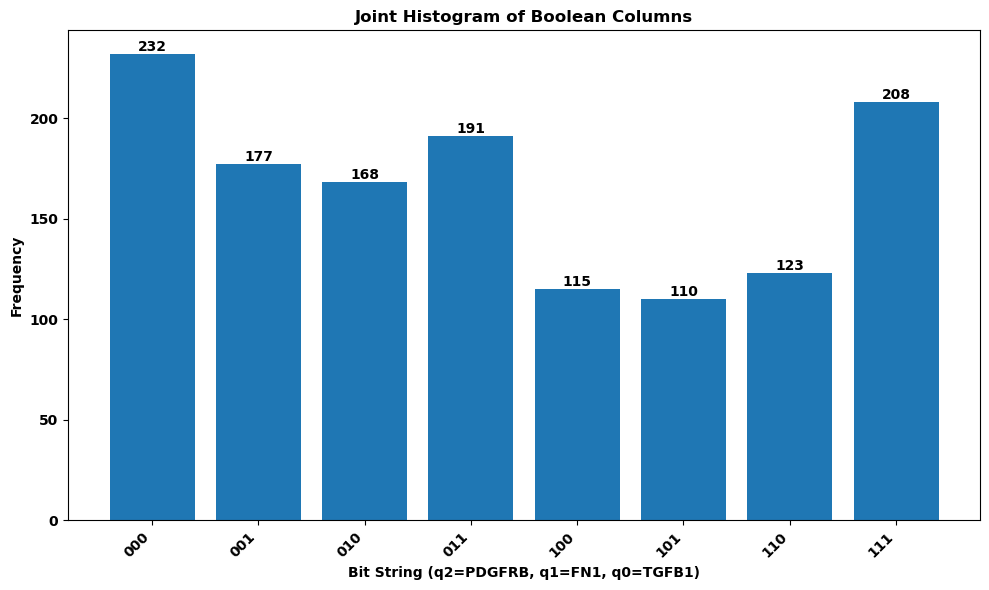

Joint Counts: Counter({'000': 232, '111': 208, '110': 191, '100': 177, '010': 168, '011': 123, '001': 115, '101': 110})
Bit Strings: ['000', '001', '010', '011', '100', '101', '110', '111']


In [7]:
joint_counts_ct2_co, bit_strings_ct2_co = create_joint_histogram(Xct2_binary_co)

num_qubits2 = Xct2_binary_co.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct2_co, num_qubits2, reverse_bits=True, features=gl_recv)  # Pass num_qubits

print("Joint Counts:", joint_counts_ct2_co)
print("Bit Strings:", bit_strings_ct2_co)

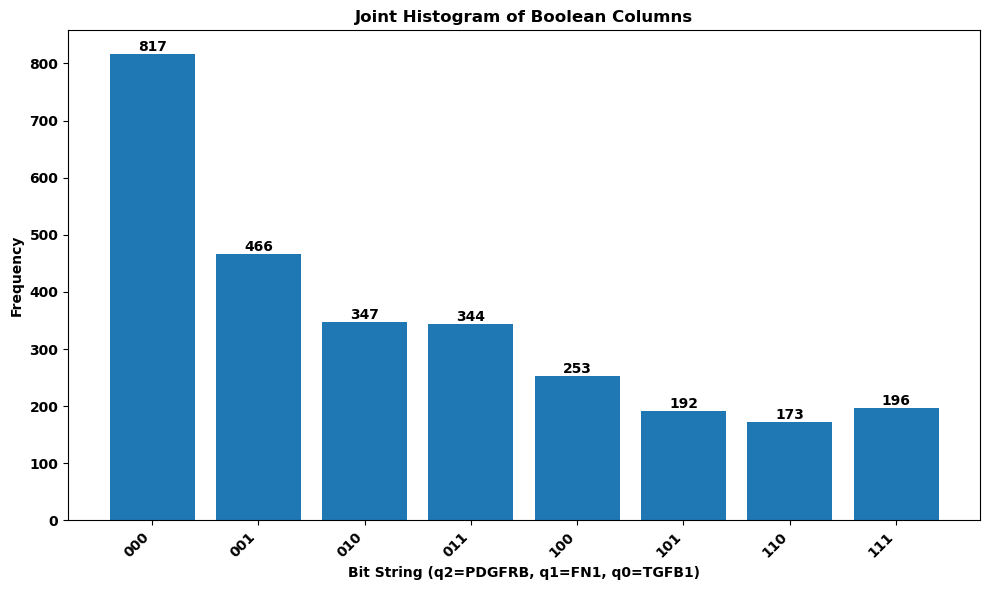

Joint Counts: Counter({'000': 817, '100': 466, '010': 347, '110': 344, '001': 253, '111': 196, '101': 192, '011': 173})
Bit Strings: ['000', '001', '010', '011', '100', '101', '110', '111']


In [8]:
joint_counts_ct2_mo, bit_strings_ct2_mo = create_joint_histogram(Xct2_binary_mo)

num_qubits2 = Xct2_binary_mo.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct2_mo, num_qubits2, reverse_bits=True, features=gl_recv)  # Pass num_qubits

print("Joint Counts:", joint_counts_ct2_mo)
print("Bit Strings:", bit_strings_ct2_mo)

In [9]:
import sys
import os

# Replace with your actual path
cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
sys.path.append(cc_grn_functions_path)

from quantum_functions import create_grn_ansatz, create_interaction_observable_from_histogram, evaluate_and_plot_ansatz
from quantum_functions import create_parameter_dictionaries, cost_func_vqe, cost_func_wrapper
from quantum_functions import create_interaction_observable_general, create_parameter_dictionaries_from_circuit, create_circuit_lr2


findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


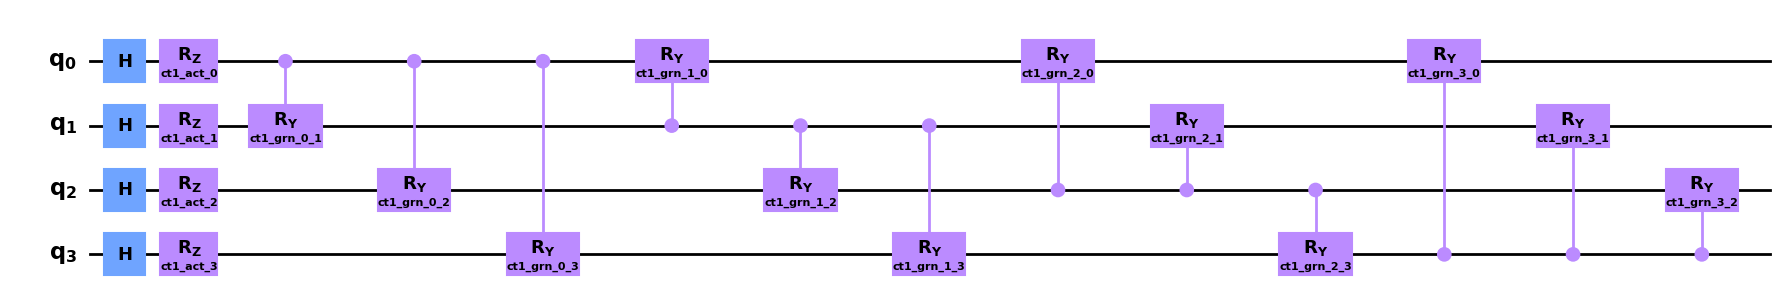

In [10]:
ng_ct1 = len(gl_source)  # Assuming gl_source is defined elsewhere
# Create mono coltured grn
ansatz_grn_ct1_mo = create_grn_ansatz(ng_ct1, "CT1")
# Create co cultured grn
ansatz_grn_ct1_co = create_grn_ansatz(ng_ct1, "CT1")
ansatz_grn_ct1_mo.draw(output="mpl", style="clifford", fold=40)

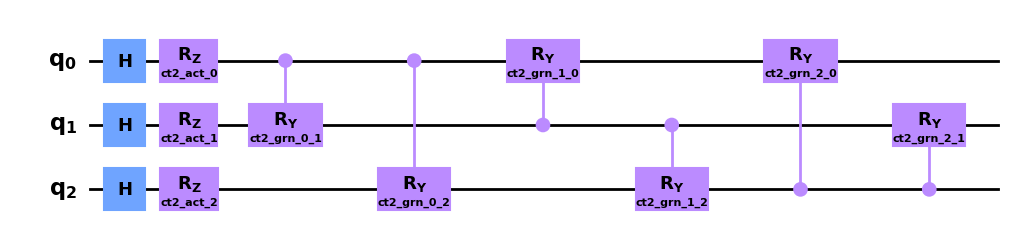

In [11]:
ng_ct2 = len(gl_recv)  #Example for a second cell type
# Create mo cultured grn
ansatz_grn_ct2_mo = create_grn_ansatz(ng_ct2, "CT2")
# Create co cultured grn
ansatz_grn_ct2_co = create_grn_ansatz(ng_ct2, "CT2")
ansatz_grn_ct2_mo.draw(output="mpl", style="clifford", fold=40)

Interaction observable CT1 from histogram: SparsePauliOp(['ZIZI', 'IZZZ', 'IZZI', 'ZZZI', 'IIZZ', 'ZIIZ', 'ZZIZ', 'ZZZZ', 'ZIZZ', 'IZIZ', 'ZZII'],
              coeffs=[ -76.+0.j,  -69.+0.j, -131.+0.j, -130.+0.j,  -40.+0.j,  -37.+0.j,
  -35.+0.j,  -92.+0.j,  -41.+0.j,  -32.+0.j,  -42.+0.j])
Static Parameters: {Parameter(ct1_act_0): 2.3550836017009766, Parameter(ct1_act_1): 2.7816647823864367, Parameter(ct1_act_2): 3.0704957901422163, Parameter(ct1_act_3): 1.8796233273953076}
Variable Parameters: [Parameter(ct1_grn_0_1), Parameter(ct1_grn_0_2), Parameter(ct1_grn_0_3), Parameter(ct1_grn_1_0), Parameter(ct1_grn_1_2), Parameter(ct1_grn_1_3), Parameter(ct1_grn_2_0), Parameter(ct1_grn_2_1), Parameter(ct1_grn_2_3), Parameter(ct1_grn_3_0), Parameter(ct1_grn_3_1), Parameter(ct1_grn_3_2)]
  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -199.39259218136837
        x: [-1.391e+00 -9.004e-02 -1.291e+00  1.386e+00 -1.580e+00
            -8.231e

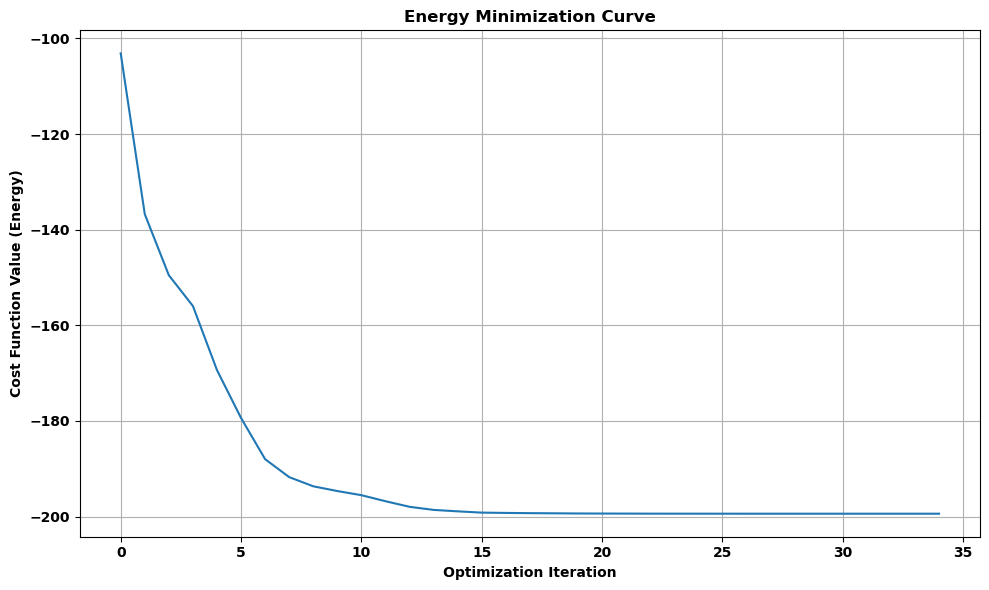

In [16]:
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize

min_ones_ct1 = 2
num_features = Xct1_binary_co.shape[1]  # Get the number of features dynamically

interaction_observable_ct1_co = create_interaction_observable_from_histogram(joint_counts_ct1_co, num_features, min_ones = min_ones_ct1, standardize=False)
print("Interaction observable CT1 from histogram:", interaction_observable_ct1_co)

static_params, variable_params = create_parameter_dictionaries(ansatz_grn_ct1_co, ct1_percentages_co)

print("Static Parameters:", static_params)
print("Variable Parameters:", variable_params)

estimator = StatevectorEstimator()

# Initialize variable parameters
x0_interaction = np.zeros(len(variable_params))  # All zeros

# Create initial full parameter dictionary - THIS IS THE KEY CHANGE
all_params_ct1_co = static_params.copy()  # Start with static parameters
all_params_ct1_co.update(dict(zip(variable_params, x0_interaction)))  # Add variable parameters

cost_values = []
# Call minimize with args
result_interaction_bfgs = minimize(
    cost_func_wrapper,
    x0_interaction,
    args=(all_params_ct1_co, ansatz_grn_ct1_co, interaction_observable_ct1_co, estimator, variable_params), # Pass all the arguments as a tuple
    method="L-BFGS-B",
    callback=lambda xk: cost_values.append(cost_func_wrapper(xk, all_params_ct1_co, ansatz_grn_ct1_co, interaction_observable_ct1_co, estimator, variable_params))
)

print(result_interaction_bfgs)

# --- 6. Results and DataFrame ---
optimized_variable_parameters = result_interaction_bfgs.x

# Update the full parameter dictionary with optimized variable parameters
for param, value in zip(variable_params, optimized_variable_parameters):
    all_params_ct1_co[param] = value

import matplotlib.pyplot as plt

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

Interaction observable CT1 from histogram: SparsePauliOp(['IZZI', 'ZZZZ', 'ZZZI', 'IZZZ', 'ZZII', 'IIZZ', 'ZIZI', 'IZIZ', 'ZIZZ', 'ZZIZ', 'ZIIZ'],
              coeffs=[-342.+0.j,  -66.+0.j, -310.+0.j,  -33.+0.j, -103.+0.j,  -27.+0.j,
 -162.+0.j,  -24.+0.j,  -21.+0.j,  -14.+0.j,  -10.+0.j])
Static Parameters: {Parameter(ct1_act_0): 2.3096819086036633, Parameter(ct1_act_1): 2.812017789761422, Parameter(ct1_act_2): 3.255880711207696, Parameter(ct1_act_3): 0.6219396623857967}
Variable Parameters: [Parameter(ct1_grn_0_1), Parameter(ct1_grn_0_2), Parameter(ct1_grn_0_3), Parameter(ct1_grn_1_0), Parameter(ct1_grn_1_2), Parameter(ct1_grn_1_3), Parameter(ct1_grn_2_0), Parameter(ct1_grn_2_1), Parameter(ct1_grn_2_3), Parameter(ct1_grn_3_0), Parameter(ct1_grn_3_1), Parameter(ct1_grn_3_2)]
  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -554.9083289634868
        x: [ 1.580e+00  1.570e+00 -1.497e+00  7.652e-01 -1.597e+00
            -2.614e+00

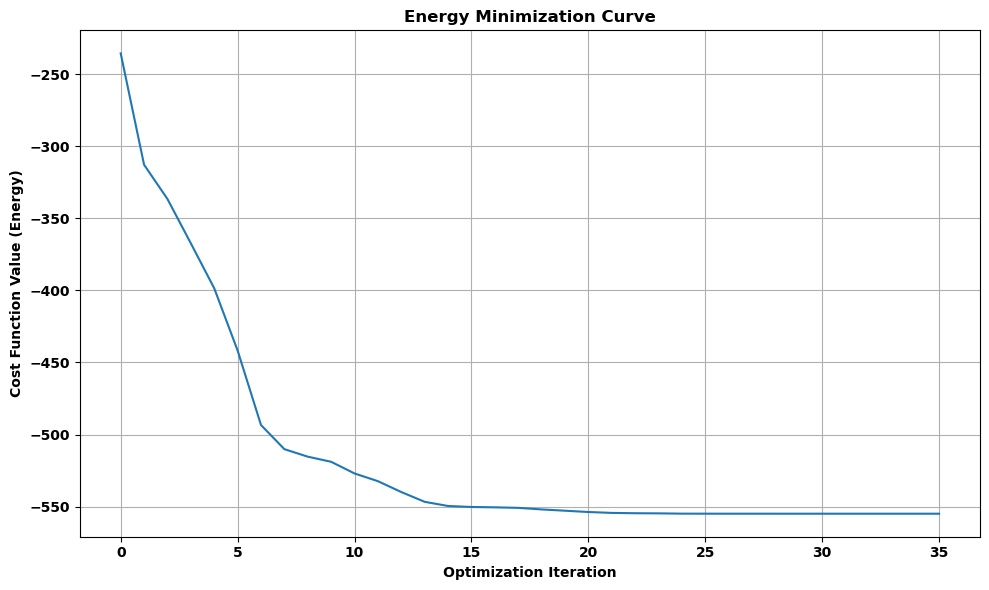

In [17]:
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize

num_features = Xct1_binary_mo.shape[1]  # Get the number of features dynamically

interaction_observable_ct1_mo = create_interaction_observable_from_histogram(joint_counts_ct1_mo, num_features, min_ones = min_ones_ct1, standardize=False)
print("Interaction observable CT1 from histogram:", interaction_observable_ct1_mo)

static_params, variable_params = create_parameter_dictionaries(ansatz_grn_ct1_mo, ct1_percentages_mo)

print("Static Parameters:", static_params)
print("Variable Parameters:", variable_params)

estimator = StatevectorEstimator()

# Initialize variable parameters
x0_interaction = np.zeros(len(variable_params))  # All zeros

# Create initial full parameter dictionary - THIS IS THE KEY CHANGE
all_params_ct1_mo = static_params.copy()  # Start with static parameters
all_params_ct1_mo.update(dict(zip(variable_params, x0_interaction)))  # Add variable parameters

cost_values = []
# Call minimize with args
result_interaction_bfgs = minimize(
    cost_func_wrapper,
    x0_interaction,
    args=(all_params_ct1_mo, ansatz_grn_ct1_mo, interaction_observable_ct1_mo, estimator, variable_params), # Pass all the arguments as a tuple
    method="L-BFGS-B",
    callback=lambda xk: cost_values.append(cost_func_wrapper(xk, all_params_ct1_mo, ansatz_grn_ct1_mo, interaction_observable_ct1_mo, estimator, variable_params))
)

print(result_interaction_bfgs)

# --- 6. Results and DataFrame ---
optimized_variable_parameters = result_interaction_bfgs.x

# Update the full parameter dictionary with optimized variable parameters
for param, value in zip(variable_params, optimized_variable_parameters):
    all_params_ct1_mo[param] = value

import matplotlib.pyplot as plt

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

The counts are: {'1111': 604, '1001': 105, '0110': 592, '0000': 86, '0001': 6, '1100': 6, '1000': 4, '0011': 2, '0111': 4, '1011': 2, '1101': 1, '0010': 2}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:121: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


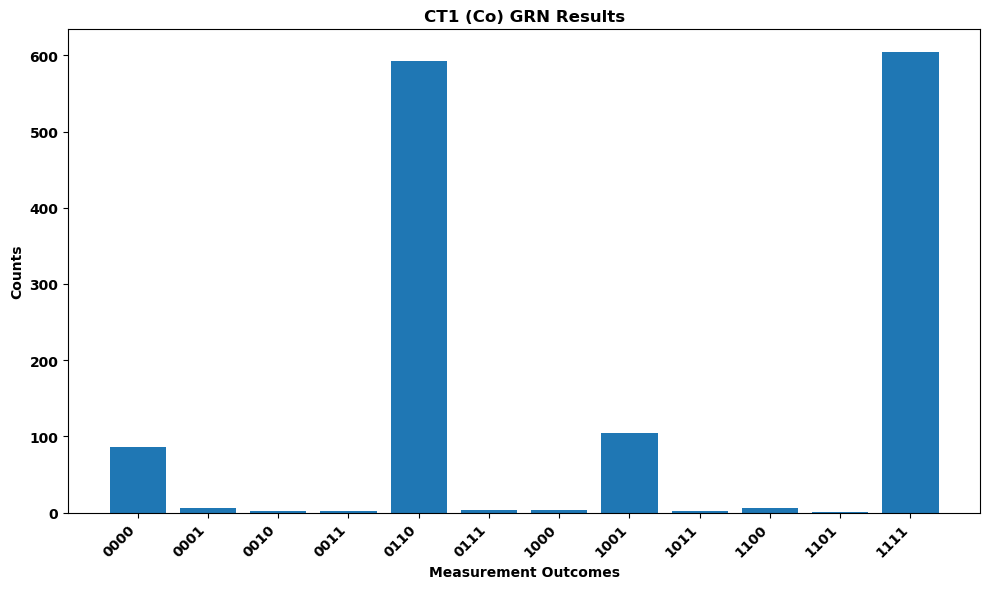

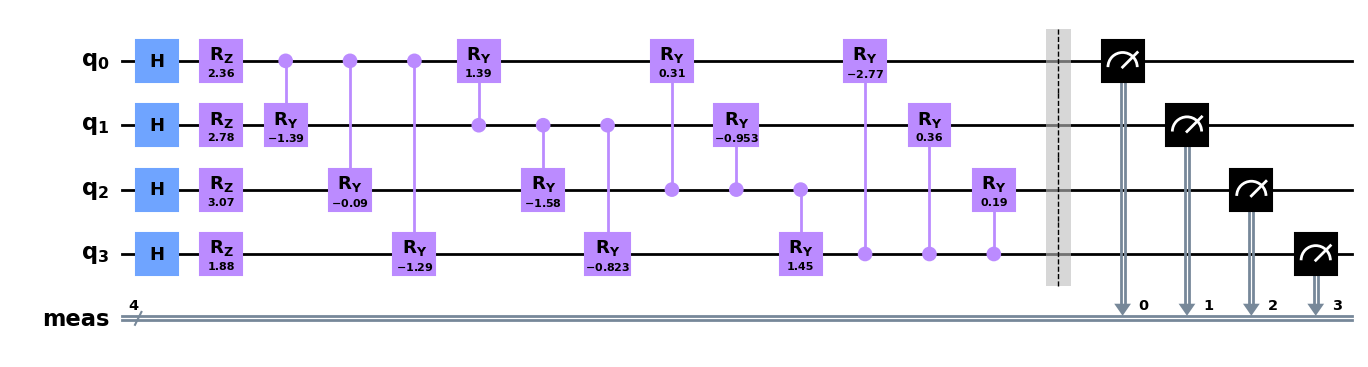

In [18]:
counts_ct1_co, bound_circuit_ct1_co = evaluate_and_plot_ansatz(ansatz_grn_ct1_co, all_params_ct1_co, shots=sum(joint_counts_ct1_co.values()), title="CT1 (Co) GRN Results")
bound_circuit_ct1_co.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

The counts are: {'0110': 517, '0001': 1053, '1111': 552, '0111': 20, '0000': 151, '1001': 20, '0100': 18, '0101': 12, '1101': 8, '1000': 1, '1011': 2, '1110': 2, '1100': 4, '1010': 2, '0011': 2}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:121: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


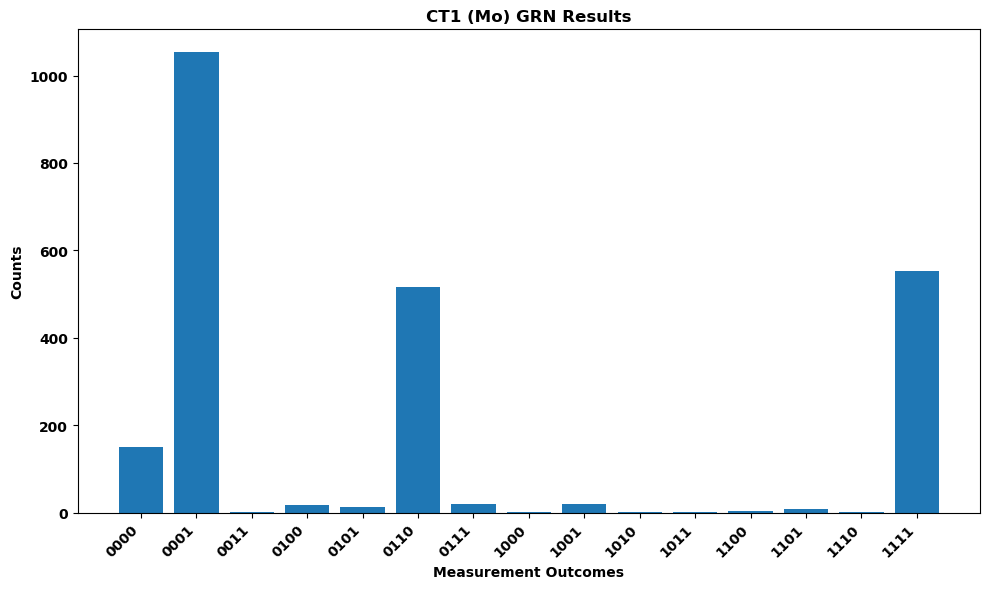

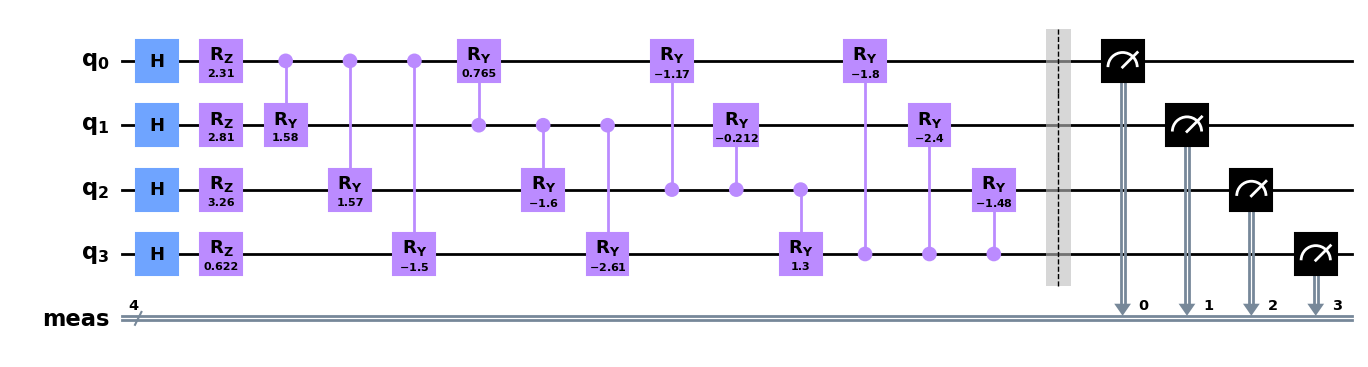

In [19]:
# Generating monocultured hitogram from ciruit
counts_ct1_mo, bound_circuit_ct1_mo = evaluate_and_plot_ansatz(ansatz_grn_ct1_mo, all_params_ct1_mo, shots=sum(joint_counts_ct1_mo.values()), title="CT1 (Mo) GRN Results")
bound_circuit_ct1_mo.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

Interaction observable CT2 from histogram: SparsePauliOp(['ZZZ', 'IZZ', 'ZZI', 'ZIZ'],
              coeffs=[-208.+0.j, -123.+0.j, -191.+0.j, -110.+0.j])
Static Parameters: {Parameter(ct2_act_0): 3.255487251303018, Parameter(ct2_act_1): 3.2744696842552226, Parameter(ct2_act_2): 2.638558180356382}
Variable Parameters: [Parameter(ct2_grn_0_1), Parameter(ct2_grn_0_2), Parameter(ct2_grn_1_0), Parameter(ct2_grn_1_2), Parameter(ct2_grn_2_0), Parameter(ct2_grn_2_1)]
  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -233.82839468125624
        x: [-1.194e+00 -4.205e-01  1.029e+00 -1.345e+00 -2.290e+00
            -7.951e-01]
      nit: 21
      jac: [ 2.839e-03  1.194e-04  1.825e-03 -3.695e-05  1.009e-03
             2.362e-03]
     nfev: 161
     njev: 23
 hess_inv: <6x6 LbfgsInvHessProduct with dtype=float64>


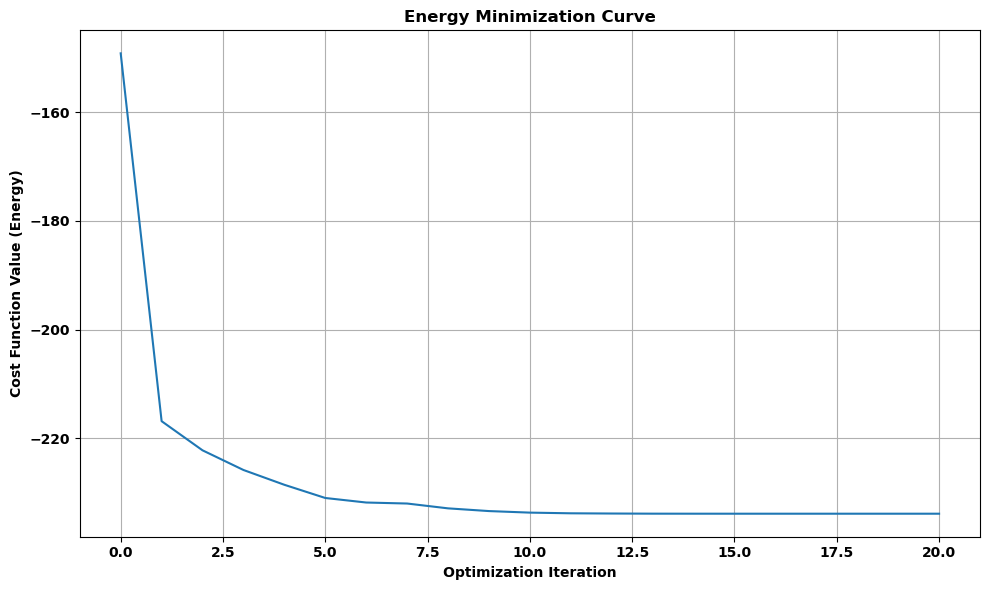

In [20]:
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize

min_ones_ct2 = 2
num_features2 = Xct2_binary_co.shape[1]  # Get the number of features dynamically

interaction_observable_ct2_co = create_interaction_observable_from_histogram(joint_counts_ct2_co, num_features2, min_ones = min_ones_ct2, standardize=False)
print("Interaction observable CT2 from histogram:", interaction_observable_ct2_co)

static_params2, variable_params2 = create_parameter_dictionaries(ansatz_grn_ct2_co, ct2_percentages_co)

print("Static Parameters:", static_params2)
print("Variable Parameters:", variable_params2)

estimator = StatevectorEstimator()
# Initialize variable parameters
x0_interaction = np.zeros(len(variable_params2))  # All zeros

# Create initial full parameter dictionary - THIS IS THE KEY CHANGE
all_params_ct2_co = static_params2.copy()  # Start with static parameters
all_params_ct2_co.update(dict(zip(variable_params2, x0_interaction)))  # Add variable parameters

cost_values = []
# Call minimize with args, using a lambda for the callback
result_interaction_bfgs = minimize(
    cost_func_wrapper,
    x0_interaction,
    args=(all_params_ct2_co, ansatz_grn_ct2_co, interaction_observable_ct2_co, estimator, variable_params2),
    method="L-BFGS-B",
    callback=lambda xk: cost_values.append(cost_func_wrapper(xk, all_params_ct2_co, ansatz_grn_ct2_co, interaction_observable_ct2_co, estimator, variable_params2))
)

print(result_interaction_bfgs)

# --- 6. Results and DataFrame ---
optimized_variable_parameters = result_interaction_bfgs.x

# Update the full parameter dictionary with optimized variable parameters
for param, value in zip(variable_params2, optimized_variable_parameters):
    all_params_ct2_co[param] = value

import matplotlib.pyplot as plt

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

Interaction observable CT2 from histogram: SparsePauliOp(['ZZZ', 'ZZI', 'IZZ', 'ZIZ'],
              coeffs=[-196.+0.j, -344.+0.j, -173.+0.j, -192.+0.j])
Static Parameters: {Parameter(ct2_act_0): 2.6998766133433083, Parameter(ct2_act_1): 2.388872462557518, Parameter(ct2_act_2): 1.8344737589828493}
Variable Parameters: [Parameter(ct2_grn_0_1), Parameter(ct2_grn_0_2), Parameter(ct2_grn_1_0), Parameter(ct2_grn_1_2), Parameter(ct2_grn_2_0), Parameter(ct2_grn_2_1)]
  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -345.3683951034478
        x: [ 1.007e+00 -1.532e+00 -1.199e+00 -1.651e+00 -1.135e+00
            -1.879e+00]
      nit: 15
      jac: [-6.423e-04  2.063e-03 -1.671e-03 -1.245e-03 -1.933e-03
            -3.843e-03]
     nfev: 126
     njev: 18
 hess_inv: <6x6 LbfgsInvHessProduct with dtype=float64>


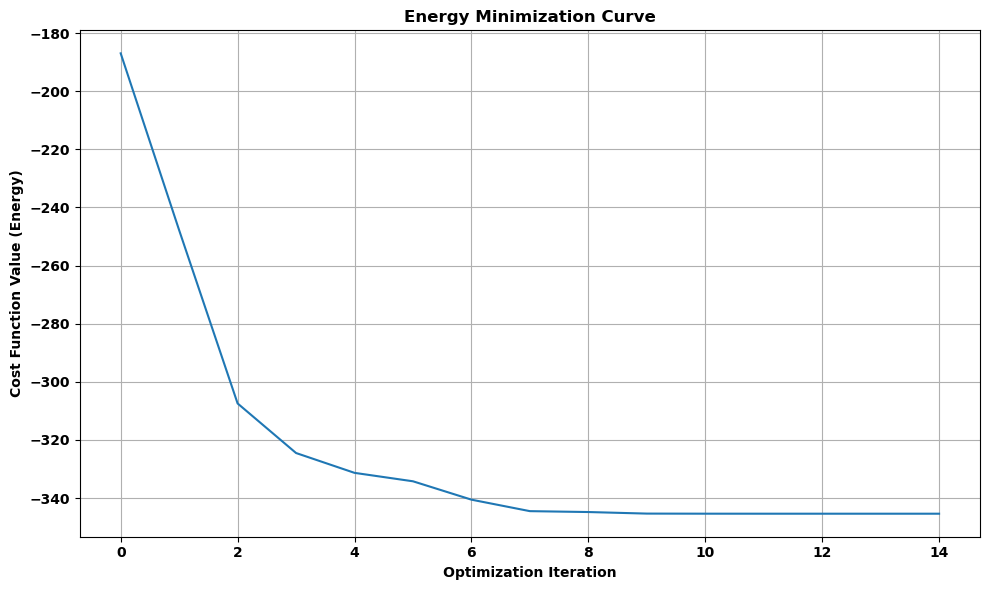

In [21]:
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize

num_features2 = Xct2_binary_mo.shape[1]  # Get the number of features dynamically

interaction_observable_ct2_mo = create_interaction_observable_from_histogram(joint_counts_ct2_mo, num_features2, min_ones = min_ones_ct2, standardize=False)
print("Interaction observable CT2 from histogram:", interaction_observable_ct2_mo)

static_params2, variable_params2 = create_parameter_dictionaries(ansatz_grn_ct2_mo, ct2_percentages_mo)

print("Static Parameters:", static_params2)
print("Variable Parameters:", variable_params2)

estimator = StatevectorEstimator()
# Initialize variable parameters
x0_interaction = np.zeros(len(variable_params2))  # All zeros

# Create initial full parameter dictionary - THIS IS THE KEY CHANGE
all_params_ct2_mo = static_params2.copy()  # Start with static parameters
all_params_ct2_mo.update(dict(zip(variable_params2, x0_interaction)))  # Add variable parameters

cost_values = []
# Call minimize with args, using a lambda for the callback
result_interaction_bfgs = minimize(
    cost_func_wrapper,
    x0_interaction,
    args=(all_params_ct2_mo, ansatz_grn_ct2_mo, interaction_observable_ct2_mo, estimator, variable_params2),
    method="L-BFGS-B",
    callback=lambda xk: cost_values.append(cost_func_wrapper(xk, all_params_ct2_mo, ansatz_grn_ct2_mo, interaction_observable_ct2_mo, estimator, variable_params2))
)

print(result_interaction_bfgs)

# --- 6. Results and DataFrame ---
optimized_variable_parameters = result_interaction_bfgs.x

# Update the full parameter dictionary with optimized variable parameters
for param, value in zip(variable_params2, optimized_variable_parameters):
    all_params_ct2_mo[param] = value

import matplotlib.pyplot as plt

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

The counts are: {'111': 831, '001': 11, '000': 112, '011': 14, '101': 20, '010': 29, '110': 4, '100': 3}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:121: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


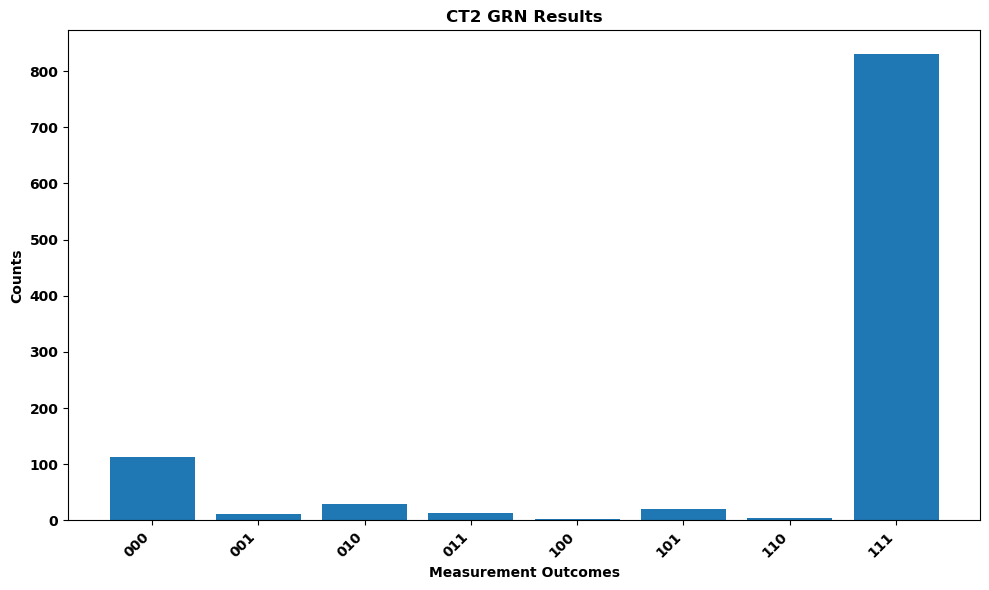

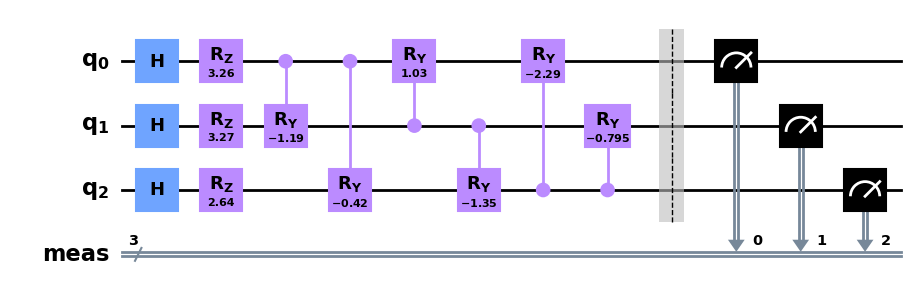

In [22]:
counts_ct2_co, bound_circuit_ct2_co = evaluate_and_plot_ansatz(ansatz_grn_ct2_co, all_params_ct2_co, title="CT2 GRN Results")
bound_circuit_ct2_co.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

The counts are: {'111': 1584, '001': 441, '000': 336, '011': 347, '110': 12, '010': 49, '100': 11, '101': 8}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:121: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


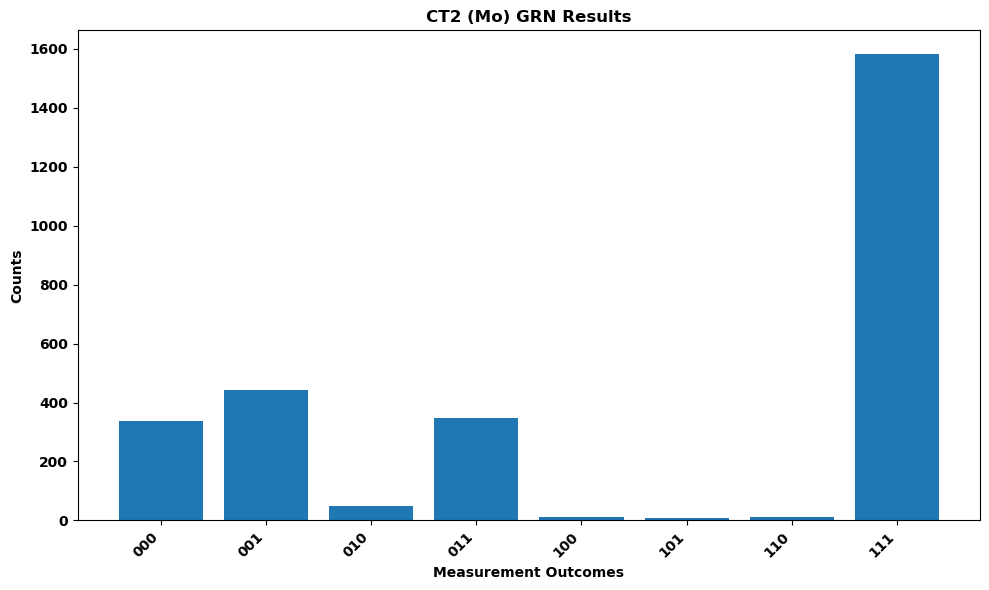

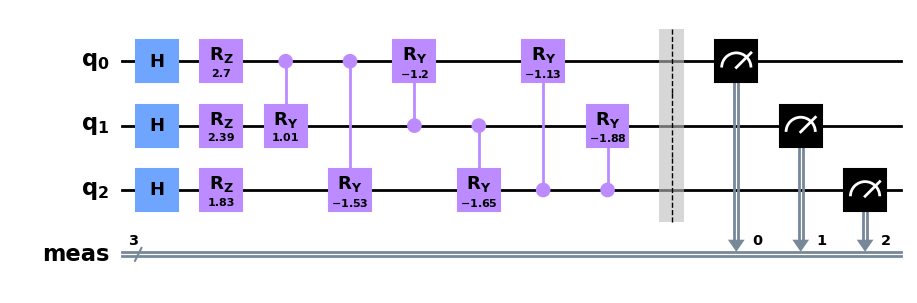

In [23]:
counts_ct2_mo, bound_circuit_ct2_mo = evaluate_and_plot_ansatz(ansatz_grn_ct2_mo, all_params_ct2_mo, shots=sum(joint_counts_ct2_mo.values()), title="CT2 (Mo) GRN Results")
bound_circuit_ct2_mo.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

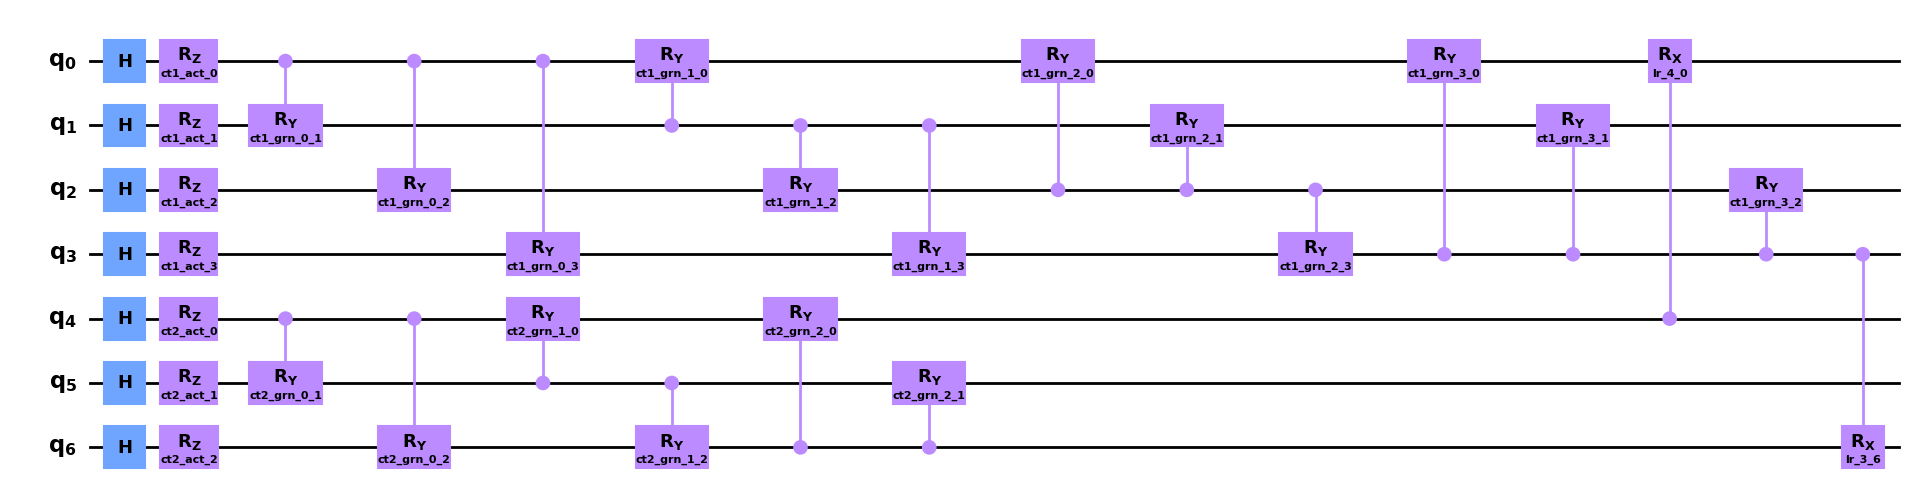

In [24]:
# interactions_lr = {
#     (4, 0): -1,
#     (3, 6): -1
# }
interactions_lr = {
    (ng_ct1, 0): -1,
    (ng_ct1-1, ng_ct1 + ng_ct2 -1): -1
}

cc_grn_circuit_mo = create_circuit_lr2(ansatz_grn_ct1_mo, ansatz_grn_ct2_mo, interactions = interactions_lr)
cc_grn_circuit_co = create_circuit_lr2(ansatz_grn_ct1_co, ansatz_grn_ct2_co, interactions = interactions_lr)
cc_grn_circuit_mo.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

{Parameter(ct1_act_0): 2.3096819086036633, Parameter(ct1_act_1): 2.812017789761422, Parameter(ct1_act_2): 3.255880711207696, Parameter(ct1_act_3): 0.6219396623857967, Parameter(ct1_grn_0_1): 1.5795041556759808, Parameter(ct1_grn_0_2): 1.569870430312734, Parameter(ct1_grn_0_3): -1.4968026224370439, Parameter(ct1_grn_1_0): 0.7651907101652308, Parameter(ct1_grn_1_2): -1.5967516335346896, Parameter(ct1_grn_1_3): -2.613946859350092, Parameter(ct1_grn_2_0): -1.1678857068991884, Parameter(ct1_grn_2_1): -0.21186581741371033, Parameter(ct1_grn_2_3): 1.2969036231265305, Parameter(ct1_grn_3_0): -1.798786070714176, Parameter(ct1_grn_3_1): -2.40153310744597, Parameter(ct1_grn_3_2): -1.4829120235056101, Parameter(ct2_act_0): 2.6998766133433083, Parameter(ct2_act_1): 2.388872462557518, Parameter(ct2_act_2): 1.8344737589828493, Parameter(ct2_grn_0_1): 1.0074311645061411, Parameter(ct2_grn_0_2): -1.5317017185501178, Parameter(ct2_grn_1_0): -1.1990994167345357, Parameter(ct2_grn_1_2): -1.650837721447747

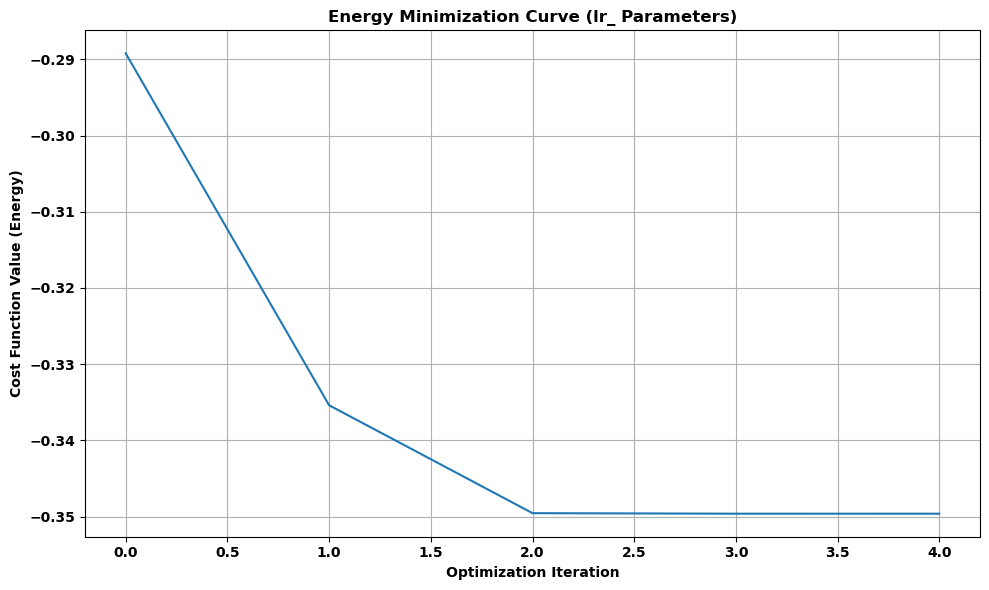

In [25]:
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector

estimator = StatevectorEstimator()

# --- 1. Create Static Parameter Dictionaries ---
static_params_lr, variable_params_lr = create_parameter_dictionaries_from_circuit(cc_grn_circuit_mo)

# Update static_params_lr with values from all_params and all_params2
for param in static_params_lr:
    if param.name in [p.name for p in all_params_ct1_mo]:
        # Access value directly by name
        static_params_lr[param] = all_params_ct1_mo[next(p for p in all_params_ct1_mo if p.name == param.name)]
    elif param.name in [p.name for p in all_params_ct2_mo]:
        # Access value directly by name
        static_params_lr[param] = all_params_ct2_mo[next(p for p in all_params_ct2_mo if p.name == param.name)]

x0_lr = np.zeros(len(variable_params_lr))  # Initial lr_ values

# Create the combined parameter dictionary.
all_params_lr_mo = static_params_lr.copy()
all_params_lr_mo.update(dict(zip(variable_params_lr.values(), x0_lr)))

print(all_params_lr_mo)

interactions = {
    (ng_ct1, 0): -1,
    (ng_ct1-1, ng_ct1 + ng_ct2 -1): -1
}

interaction_observable_lr_mo = create_interaction_observable_general(interactions, ng_ct1 + ng_ct2)
print("Interaction observable LR custom: ", interaction_observable_lr_mo)

cost_values = []
result_lr_bfgs = minimize(
    cost_func_wrapper, 
    x0_lr,
    args=(all_params_lr_mo, cc_grn_circuit_mo, interaction_observable_lr_mo, estimator, variable_params_lr),  # Correct args
    method="L-BFGS-B",
    callback=lambda xk: cost_values.append(cost_func_wrapper(xk, all_params_lr_mo, cc_grn_circuit_mo, interaction_observable_lr_mo, estimator, variable_params_lr))  # Correct callback
)

print(result_lr_bfgs)

# --- 6. Results and DataFrame ---
optimized_lr_values = result_lr_bfgs.x

# Update the lr_ parameters in the combined dictionary (optional)
all_params_lr_mo.update(dict(zip(variable_params_lr, optimized_lr_values)))

# --- 7. Plotting ---
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve (lr_ Parameters)")
plt.grid(True)
plt.tight_layout()
plt.show()

The counts are: {'1110001': 126, '0010000': 44, '1110111': 35, '1110000': 161, '1111111': 112, '0010110': 25, '1110110': 101, '1111101': 4, '0000001': 53, '1111110': 61, '0110001': 29, '1011111': 9, '0110000': 34, '0000000': 10, '0110110': 16, '1110101': 6, '0110111': 8, '1111001': 2, '0000110': 38, '1101111': 5, '0010001': 30, '0010111': 8, '0100110': 5, '0011111': 12, '1101011': 1, '0111110': 4, '0111111': 7, '1001111': 11, '0011000': 1, '1110010': 2, '1111000': 3, '0001111': 24, '0001011': 1, '1011100': 1, '0101010': 1, '1011110': 2, '0101111': 2, '1011001': 1, '1000001': 1, '0100001': 7, '1111010': 1, '0100000': 1, '0011110': 8, '1100110': 1, '1010001': 1, '1101101': 1, '0110101': 1, '0110010': 2, '0000111': 1, '1111100': 1, '0010010': 1, '0001100': 1, '0010101': 1}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:121: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


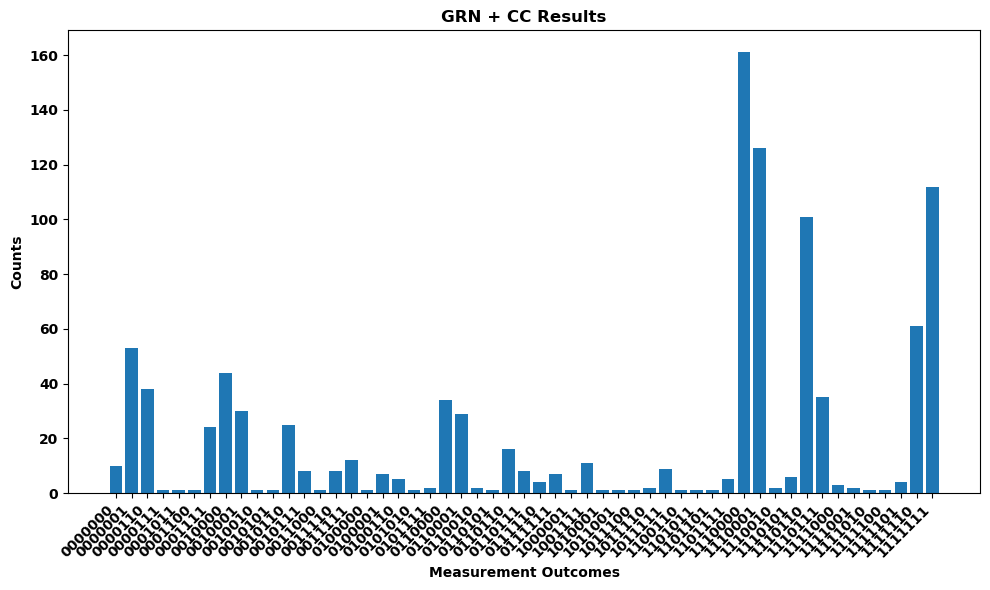

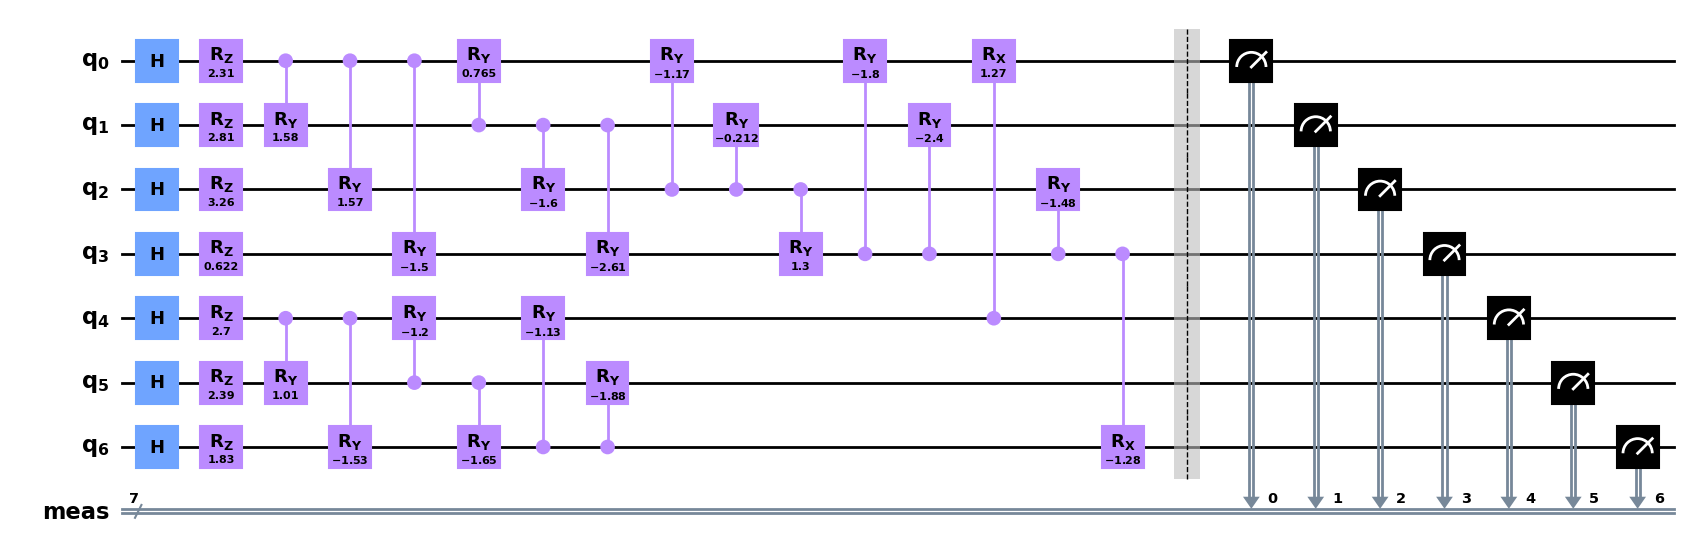

In [26]:
counts_cc_grn_mo, bound_circuit_cc_grn_mo = evaluate_and_plot_ansatz(cc_grn_circuit_mo, all_params_lr_mo, shots=1024, title="GRN + CC Results")
bound_circuit_cc_grn_mo.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

{Parameter(ct1_act_0): 2.3550836017009766, Parameter(ct1_act_1): 2.7816647823864367, Parameter(ct1_act_2): 3.0704957901422163, Parameter(ct1_act_3): 1.8796233273953076, Parameter(ct1_grn_0_1): -1.3912488689078386, Parameter(ct1_grn_0_2): -0.09003623557243813, Parameter(ct1_grn_0_3): -1.2914182329713977, Parameter(ct1_grn_1_0): 1.3864431859182729, Parameter(ct1_grn_1_2): -1.5799189088975443, Parameter(ct1_grn_1_3): -0.8230836397501335, Parameter(ct1_grn_2_0): 0.31037164040765336, Parameter(ct1_grn_2_1): -0.9530513246322364, Parameter(ct1_grn_2_3): 1.4487557448257355, Parameter(ct1_grn_3_0): -2.7742188947535023, Parameter(ct1_grn_3_1): 0.359626626493958, Parameter(ct1_grn_3_2): 0.1900822015745531, Parameter(ct2_act_0): 3.255487251303018, Parameter(ct2_act_1): 3.2744696842552226, Parameter(ct2_act_2): 2.638558180356382, Parameter(ct2_grn_0_1): -1.1943631105263428, Parameter(ct2_grn_0_2): -0.4204821237932263, Parameter(ct2_grn_1_0): 1.0289516881576348, Parameter(ct2_grn_1_2): -1.3451846555

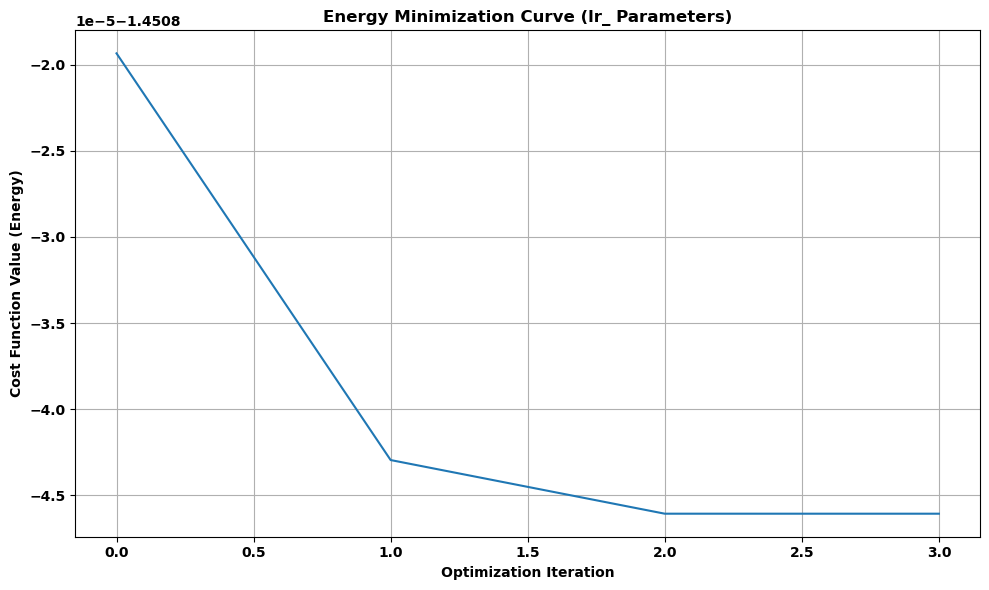

In [27]:
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector

estimator = StatevectorEstimator()

# --- 1. Create Static Parameter Dictionaries ---
static_params_lr, variable_params_lr = create_parameter_dictionaries_from_circuit(cc_grn_circuit_co)

# Update static_params_lr with values from all_params and all_params2
for param in static_params_lr:
    if param.name in [p.name for p in all_params_ct1_co]:
        # Access value directly by name
        static_params_lr[param] = all_params_ct1_co[next(p for p in all_params_ct1_co if p.name == param.name)]
    elif param.name in [p.name for p in all_params_ct2_co]:
        # Access value directly by name
        static_params_lr[param] = all_params_ct2_co[next(p for p in all_params_ct2_co if p.name == param.name)]

x0_lr = np.zeros(len(variable_params_lr))  # Initial lr_ values

# Create the combined parameter dictionary.
all_params_lr_co = static_params_lr.copy()
all_params_lr_co.update(dict(zip(variable_params_lr.values(), x0_lr)))

print(all_params_lr_co)


interactions = {
    (ng_ct1, 0): -1,
    (ng_ct1-1, ng_ct1 + ng_ct2 -1): -1
}

interaction_observable_lr_co = create_interaction_observable_general(interactions, ng_ct1 + ng_ct2)
print("Interaction observable LR custom: ", interaction_observable_lr_co)

cost_values = []
result_lr_bfgs = minimize(
    cost_func_wrapper, 
    x0_lr,
    args=(all_params_lr_co, cc_grn_circuit_co, interaction_observable_lr_co, estimator, variable_params_lr),  # Correct args
    method="L-BFGS-B",
    callback=lambda xk: cost_values.append(cost_func_wrapper(xk, all_params_lr_co, cc_grn_circuit_co, interaction_observable_lr_co, estimator, variable_params_lr))  # Correct callback
)

print(result_lr_bfgs)

# --- 6. Results and DataFrame ---
optimized_lr_values = result_lr_bfgs.x

# Update the lr_ parameters in the combined dictionary (optional)
all_params_lr_co.update(dict(zip(variable_params_lr, optimized_lr_values)))

# --- 7. Plotting ---
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve (lr_ Parameters)")
plt.grid(True)
plt.tight_layout()
plt.show()


The counts are: {'1111111': 310, '1110110': 351, '1011111': 13, '1110000': 57, '0000110': 63, '0001111': 59, '1111001': 57, '1111101': 2, '0000000': 11, '1110100': 1, '1111011': 1, '0101111': 13, '0100110': 14, '0001001': 13, '1010110': 10, '1000000': 2, '0010110': 5, '0110110': 9, '0010000': 2, '0011111': 1, '0000001': 2, '1010000': 2, '0100000': 5, '1111100': 2, '0111001': 2, '1101001': 1, '0111111': 5, '1001111': 2, '0001000': 1, '0101001': 2, '1100110': 1, '1110011': 1, '1111000': 1, '1000110': 1, '1110001': 1, '0110000': 1}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:121: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


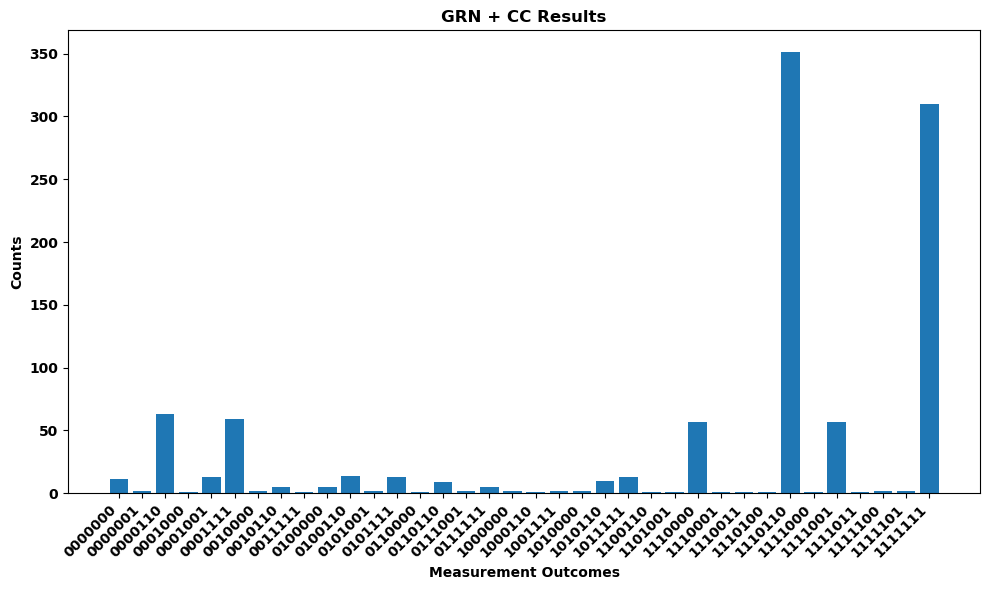

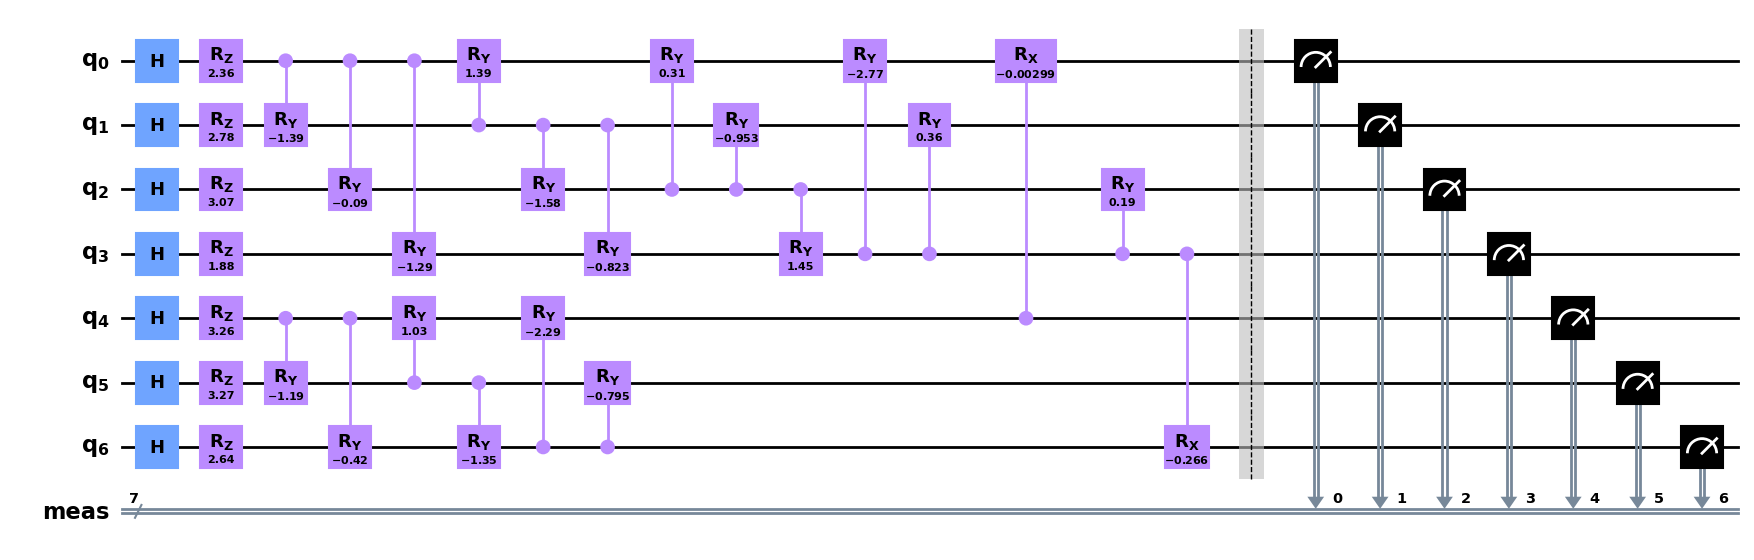

In [28]:
counts_cc_grn_co, bound_circuit_cc_grn_co = evaluate_and_plot_ansatz(cc_grn_circuit_co, all_params_lr_co, shots=1024, title="GRN + CC Results")
bound_circuit_cc_grn_co.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

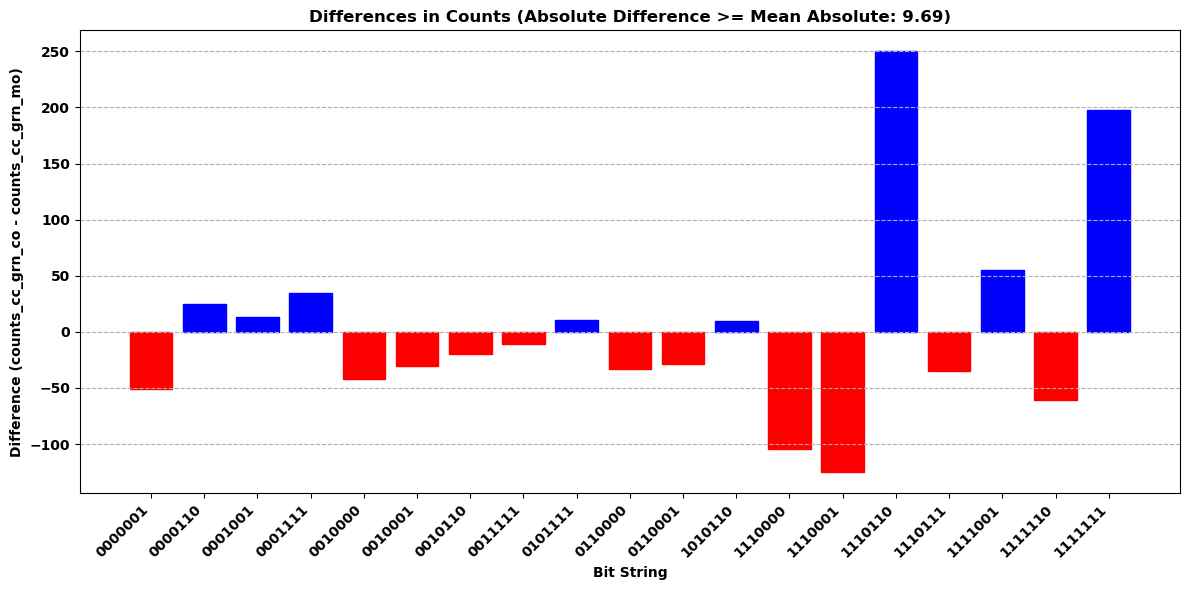

In [29]:
import matplotlib.pyplot as plt
import numpy as np

final_gl = gl_source + gl_recv
final_gl = final_gl[::-1]

differences = {}

# Calculate the differences, handling cases where bitstrings are not common
all_bitstrings = set(counts_cc_grn_co.keys()) | set(counts_cc_grn_mo.keys())

for key in all_bitstrings:
    count_co = counts_cc_grn_co.get(key, 0)
    count_mo = counts_cc_grn_mo.get(key, 0)
    differences[key] = count_co - count_mo

# Extract data for plotting
bitstrings = list(differences.keys())
difference_values = list(differences.values())

# Calculate the mean of the absolute differences
absolute_differences = [abs(diff) for diff in difference_values]
mean_absolute_difference = np.mean(absolute_differences) / 2
#mean_absolute_difference = 0 # You had this set to 0, which would plot everything

# Filter out values below the mean of the absolute differences
filtered_bitstrings = []
filtered_differences = []

for i in range(len(difference_values)):
    # if abs(difference_values[i]) >= mean_absolute_difference: # Original condition
    if difference_values[i] >= mean_absolute_difference or difference_values[i] <= -mean_absolute_difference:
        filtered_bitstrings.append(bitstrings[i])
        filtered_differences.append(difference_values[i])

# Sort the filtered bitstrings for better visualization
sorted_indices = np.argsort(filtered_bitstrings)
filtered_bitstrings = [filtered_bitstrings[i] for i in sorted_indices]
filtered_differences = [filtered_differences[i] for i in sorted_indices]

# Create the bar plot with filtered data
plt.figure(figsize=(12, 6))
bars = plt.bar(filtered_bitstrings, filtered_differences, edgecolor='black')

# Color the bars based on the sign of the difference
for bar, diff in zip(bars, filtered_differences):
    if diff > 0:
        bar.set_color('blue')  # Or another color for positive differences
    else:
        bar.set_color('red')   # Or another color for negative differences

plt.xlabel('Bit String')
plt.ylabel('Difference (counts_cc_grn_co - counts_cc_grn_mo)')
plt.title(f'Differences in Counts (Absolute Difference >= Mean Absolute: {mean_absolute_difference:.2f})')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--')
plt.show()

# if 'final_gl' in locals():
#     print(final_gl)


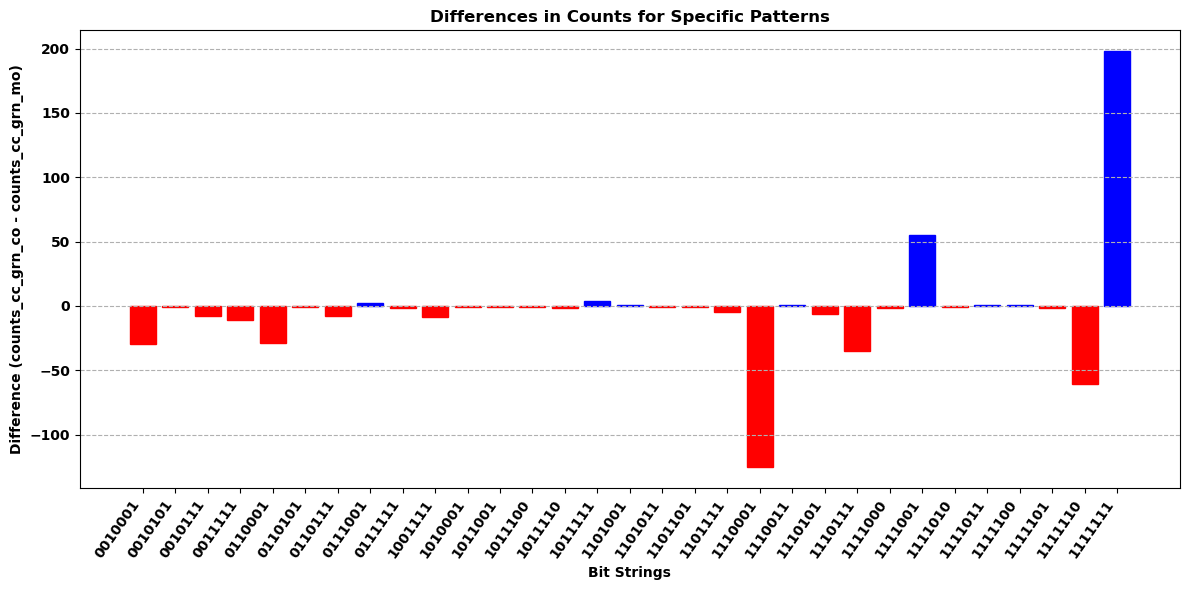

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

differences = {}

# Calculate the differences, handling cases where bitstrings are not common
all_bitstrings = set(counts_cc_grn_co.keys()) | set(counts_cc_grn_mo.keys())

for key in all_bitstrings:
    count_co = counts_cc_grn_co.get(key, 0)
    count_mo = counts_cc_grn_mo.get(key, 0)
    differences[key] = count_co - count_mo

# Define the patterns you are interested in
patterns = ["1.11..1"]  # Using '.' as a wildcard
#patterns = ["1.11..1", "1..1...", "..1...1"]  # Using '.' as a wildcard

def matches_pattern(bitstring, pattern):
    if len(bitstring) != len(pattern):
        return False
    for i in range(len(bitstring)):
        if pattern[i] != '.' and pattern[i] != bitstring[i]:
            return False
    return True

# Filter bitstrings based on the defined patterns
filtered_bitstrings = []
filtered_differences = []

for bitstring, difference in differences.items():
    for pattern in patterns:
        if matches_pattern(bitstring, pattern):
            filtered_bitstrings.append(bitstring)
            filtered_differences.append(difference)
            break # Move to the next bitstring once a match is found

# Sort the filtered bitstrings for better visualization
sorted_indices = np.argsort(filtered_bitstrings)
filtered_bitstrings = [filtered_bitstrings[i] for i in sorted_indices]
filtered_differences = [filtered_differences[i] for i in sorted_indices]

# Create the bar plot with filtered data
plt.figure(figsize=(12, 6))
bars = plt.bar(filtered_bitstrings, filtered_differences, edgecolor='black')

# Color the bars based on the sign of the difference
for bar, diff in zip(bars, filtered_differences):
    if diff > 0:
        bar.set_color('blue')  # Or another color for positive differences
    else:
        bar.set_color('red')   # Or another color for negative differences



plt.xlabel('Bit Strings')
plt.ylabel('Difference (counts_cc_grn_co - counts_cc_grn_mo)')
plt.title(f'Differences in Counts for Specific Patterns')
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--')
plt.show()

# if 'final_gl' in locals():
#     print(final_gl)

In [34]:
print(gl_recv[::-1], gl_source[::-1])

['PDGFRB', 'FN1', 'TGFB1'] ['PDGFB', 'HIF1A', 'SMAD3', 'TGFBR2']


In [ ]:
# Create x-axis label with feature mapping
#gl_reverse = gl_recv[::-1], gl_source[::-1]
features = gl_source, gl_recv
featires = None
reverse_bits = True
if features is not None:
    if reverse_bits:
        xlabel_text = f"Bit String ("
        for i in range(num_qubits - 1, -1, -1):  # Iterate in reverse order for qn ... q0
            xlabel_text += f"q{i}={features[i]}, "
        xlabel_text = xlabel_text[:-2] + ")"  # Remove trailing comma and space
        plt.xlabel(xlabel_text)
    else:
        xlabel_text = f"Bit String ("
        for i in range(0, num_qubits):
            xlabel_text += f"q{i}={features[i]}, "
        xlabel_text = xlabel_text[:-2] + ")"
else:
    if reverse_bits:
        xlabel_text = f"Bit String (q{num_qubits-1} ... q0)"
    else:
        xlabel_text = f"Bit String (q0 ... q{num_qubits-1})"
        plt.xlabel()